# D2 Forestry Management Workflow — GeoPrompt

Stand risk scoring, proximity analysis, and forest management scenarios.


In [1]:
from __future__ import annotations

import json, os

from pathlib import Path

from urllib.error import URLError

from urllib.request import Request, urlopen

import matplotlib.pyplot as plt



_ROOT = Path.cwd()
if (_ROOT / "examples" / "notebooks").exists():
    OUTPUT_DIR = _ROOT / "examples" / "notebooks" / "geoprompt" / "outputs"
else:
    OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ALLOW_LIVE_API = os.getenv("GEOPROMPT_ALLOW_LIVE_API", "0") == "1"



def fetch_json(url, fallback):

    if not ALLOW_LIVE_API:

        return fallback

    try:

        req = Request(url, headers={"User-Agent": "geoprompt-notebook/2.0"})

        with urlopen(req, timeout=6) as r:

            return json.loads(r.read().decode("utf-8"))

    except (URLError, TimeoutError, ValueError):

        return fallback



def fetch_first_json(urls, validator, fallback):

    for url in urls:

        payload = fetch_json(url, None)

        if payload is not None and validator(payload):

            return payload, url, True

    return fallback, "fallback", False



import geoprompt as gp

from geoprompt import GeoPromptFrame, write_geojson

from geoprompt.tools import build_scenario_report, export_scenario_report

print("Imports OK")


Imports OK


## Section A: Pull Data Sources


In [2]:
forest = {"features": [{"id": "fallback-forest"}]}
weather = {"properties": {"forecast": "fallback"}}
forecast = {"hourly": {"temperature_2m": [0.0]}}

forest, forest_src, forest_live = fetch_first_json(
    [
        "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_day.geojson",
        "https://api.github.com/repos/opengeospatial/geopandas",
    ],
    lambda d: isinstance(d, dict) and bool(d.get("features") or d.get("id")),
    forest,
)
weather, wx_src, wx_live = fetch_first_json(
    [
        "https://api.weather.gov/points/44.05,-121.31",
        "https://api.weather.gov/points/45.52,-122.67",
    ],
    lambda d: isinstance(d, dict) and bool(d.get("properties", {}).get("forecast")),
    weather,
)
forecast, fc_src, fc_live = fetch_first_json(
    [
        "https://api.open-meteo.com/v1/forecast?latitude=44.05&longitude=-121.31&hourly=temperature_2m&forecast_days=1",
        "https://api.open-meteo.com/v1/forecast?latitude=45.52&longitude=-122.67&hourly=temperature_2m&forecast_days=1",
    ],
    lambda d: isinstance(d, dict) and len(d.get("hourly", {}).get("temperature_2m", [])) > 0,
    forecast,
)

forest_count = len(forest.get("features", [])) if isinstance(forest, dict) else 0
if forest_count == 0 and isinstance(forest, dict) and forest.get("id"):
    forest_count = 1
print(f"Forestry records: {forest_count} | live={forest_live} | source={forest_src}")
print(f"NOAA forecast exists: {bool(weather.get('properties', {}).get('forecast'))} | live={wx_live} | source={wx_src}")
print(f"Open-Meteo hourly points: {len(forecast.get('hourly', {}).get('temperature_2m', []))} | live={fc_live} | source={fc_src}")


Forestry records: 1 | live=False | source=fallback
NOAA forecast exists: True | live=False | source=fallback
Open-Meteo hourly points: 1 | live=False | source=fallback


## Section B: Spatial Analysis


Nearest neighbors (top 3 pairs):
  S6 -> S3  dist=11.8066
  S6 -> S4  dist=35.4266
  S3 -> S6  dist=11.8066

Stands within 0.5 deg of S3: ['S6', 'S4', 'S2']
Buffer zones: 6 polygons

Proximity join results (stand -> nearest station): [('S6', 'FS2'), ('S6', 'FS1'), ('S3', 'FS2'), ('S3', 'FS1')]

Dissolved by risk tier:
  HIGH: mean_risk=0.968
  HIGH: mean_risk=0.968
  MED: mean_risk=0.720
  MED: mean_risk=0.720
  LOW: mean_risk=0.499
  LOW: mean_risk=0.499

Stands in southern zone: ['S2', 'S5']

Frame summary:
{
  "row_count": 6,
  "column_count": 9,
  "columns": [
    "stand_id",
    "fuel_load",
    "slope",
    "dist_km",
    "zone",
    "geometry",
    "risk_score",
    "risk_tier",
    "priority_rank"
  ],
  "crs": "EPSG:4326",
  "geometry_column": "geometry",
  "geometry_types": [
    "Point"
  ],
  "bounds": {
    "min_x": -121.6,
    "min_y": 43.9,
    "max_x": -120.8,
    "max_y": 44.5
  },
  "column_stats": [
    {
      "column": "stand_id",
      "dtype": "string",
      "nu

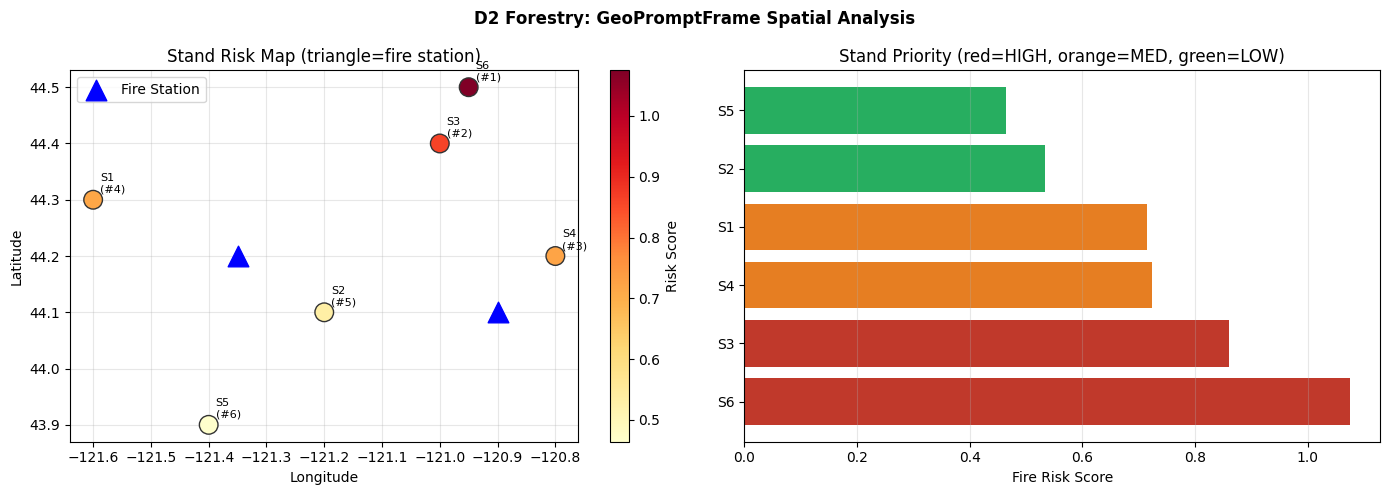

Wrote basemap snapshot: d2-gp-basemap.html


In [3]:
RAW_STANDS = [

    {"stand_id": "S1", "fuel_load": 0.72, "slope": 0.35, "dist_km": 0.8,  "zone": "A",

     "geometry": {"type": "Point", "coordinates": [-121.60, 44.30]}},

    {"stand_id": "S2", "fuel_load": 0.63, "slope": 0.25, "dist_km": 1.4,  "zone": "A",

     "geometry": {"type": "Point", "coordinates": [-121.20, 44.10]}},

    {"stand_id": "S3", "fuel_load": 0.81, "slope": 0.41, "dist_km": 0.6,  "zone": "B",

     "geometry": {"type": "Point", "coordinates": [-121.00, 44.40]}},

    {"stand_id": "S4", "fuel_load": 0.77, "slope": 0.39, "dist_km": 0.9,  "zone": "B",

     "geometry": {"type": "Point", "coordinates": [-120.80, 44.20]}},

    {"stand_id": "S5", "fuel_load": 0.58, "slope": 0.21, "dist_km": 1.8,  "zone": "A",

     "geometry": {"type": "Point", "coordinates": [-121.40, 43.90]}},

    {"stand_id": "S6", "fuel_load": 0.88, "slope": 0.45, "dist_km": 0.4,  "zone": "B",

     "geometry": {"type": "Point", "coordinates": [-120.95, 44.50]}},

]

FIRE_STATIONS = [

    {"station_id": "FS1", "geometry": {"type": "Point", "coordinates": [-121.35, 44.20]}},

    {"station_id": "FS2", "geometry": {"type": "Point", "coordinates": [-120.90, 44.10]}},

]



enriched = []

for row in RAW_STANDS:

    fuel = float(row["fuel_load"]); slope = float(row["slope"]); dist = float(row["dist_km"])

    risk = round(fuel * 0.5 + slope * 0.3 + (1.0 / dist) * 0.2, 4)

    risk_tier = "HIGH" if risk > 0.75 else ("MED" if risk > 0.55 else "LOW")

    enriched.append({**row, "risk_score": risk, "risk_tier": risk_tier})

enriched.sort(key=lambda r: -r["risk_score"])

for rank, row in enumerate(enriched, 1):

    row["priority_rank"] = rank



# Build GeoPromptFrame

stands_frame = GeoPromptFrame(enriched, geometry_column="geometry", crs="EPSG:4326")

stations_frame = GeoPromptFrame(FIRE_STATIONS, geometry_column="geometry", crs="EPSG:4326")



# 1. Nearest neighbors between stands

neighbors = stands_frame.nearest_neighbors(id_column="stand_id", k=2, distance_method="haversine")

print("Nearest neighbors (top 3 pairs):")

for nb in neighbors[:3]:

    print(f"  {nb['origin']} -> {nb['neighbor']}  dist={nb['distance']:.4f}")



# 2. Query radius: stands near S3 (high-risk)

near_s3 = stands_frame.query_radius("S3", max_distance=0.5, id_column="stand_id")

print(f"\nStands within 0.5 deg of S3: {[r['stand_id'] for r in near_s3.to_records()]}")



# 3. Buffer protection zones (0.15 degree radius)

buffers = stands_frame.buffer(0.15)

print(f"Buffer zones: {len(buffers)} polygons")



# 4. Proximity join: stands within 0.6 deg of fire stations

pj = stands_frame.proximity_join(stations_frame, max_distance=0.6, how="left")

assigned = [(r["stand_id"], r.get("station_id")) for r in pj.to_records()]

print(f"\nProximity join results (stand -> nearest station): {assigned[:4]}")



# 5. Dissolve by risk tier: aggregate risk scores

dissolved = stands_frame.dissolve(by="risk_tier", aggregations={"risk_score": "mean", "fuel_load": "mean"})

print("\nDissolved by risk tier:")

for row in dissolved.to_records():

    print(f"  {row['risk_tier']}: mean_risk={row.get('risk_score_mean_risk_tier',row.get('risk_score','?')):.3f}")



# 6. Query bounds: high-risk southern zone

south_stands = stands_frame.query_bounds(-121.65, 43.85, -120.75, 44.15)

print(f"\nStands in southern zone: {[r['stand_id'] for r in south_stands.to_records()]}")



# Write GeoJSON

write_geojson(OUTPUT_DIR / "d2-gp-stands.geojson", stands_frame)

print("\nFrame summary:")

print(json.dumps(stands_frame.summary(), indent=2, default=str))



# Inline visualization

records = stands_frame.to_records()

lons = [float(r["geometry"]["coordinates"][0]) for r in records]

lats = [float(r["geometry"]["coordinates"][1]) for r in records]

risks = [float(r["risk_score"]) for r in records]

labels = [str(r["stand_id"]) for r in records]

ranks = [int(r["priority_rank"]) for r in records]



fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(lons, lats, c=risks, cmap="YlOrRd", s=180, edgecolors="#333", zorder=5)

for lon, lat, lbl, rank in zip(lons, lats, labels, ranks):

    axes[0].annotate(f"{lbl}\n(#{rank})", (lon, lat), textcoords="offset points", xytext=(5, 5), fontsize=8)

slons = [float(r["geometry"]["coordinates"][0]) for r in FIRE_STATIONS]

slats = [float(r["geometry"]["coordinates"][1]) for r in FIRE_STATIONS]

axes[0].scatter(slons, slats, c="blue", s=220, marker="^", zorder=6, label="Fire Station")

plt.colorbar(sc, ax=axes[0], label="Risk Score")

axes[0].set_title("Stand Risk Map (triangle=fire station)")

axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

axes[0].legend(); axes[0].grid(True, alpha=0.3)



sorted_recs = sorted(records, key=lambda r: -float(r["risk_score"]))

bar_colors = ["#c0392b" if r["risk_tier"]=="HIGH" else ("#e67e22" if r["risk_tier"]=="MED" else "#27ae60")

              for r in sorted_recs]

axes[1].barh([r["stand_id"] for r in sorted_recs], [float(r["risk_score"]) for r in sorted_recs], color=bar_colors)

axes[1].set_xlabel("Fire Risk Score")

axes[1].set_title("Stand Priority (red=HIGH, orange=MED, green=LOW)")

axes[1].grid(True, axis="x", alpha=0.3)

plt.suptitle("D2 Forestry: GeoPromptFrame Spatial Analysis", fontweight="bold")

plt.tight_layout(); plt.show()

# Basemap snapshot (real tiled basemap, saved as HTML)
try:
    import folium
    if records:
        label_candidates = ["node", "stand_id", "asset_id", "zone_id"]
        label_col = next((c for c in label_candidates if c in records[0]), list(records[0].keys())[0])
        coords = [r.get("geometry", {}).get("coordinates", [0.0, 0.0]) for r in records]
        lons_bm = [float(c[0]) for c in coords]
        lats_bm = [float(c[1]) for c in coords]
        fmap = folium.Map(
            location=[sum(lats_bm) / len(lats_bm), sum(lons_bm) / len(lons_bm)],
            zoom_start=10,
            tiles="CartoDB positron",
        )
        for row in records:
            coords_row = row.get("geometry", {}).get("coordinates", [None, None])
            if coords_row[0] is None or coords_row[1] is None:
                continue
            folium.CircleMarker(
                location=[float(coords_row[1]), float(coords_row[0])],
                radius=6,
                color="#1d4ed8",
                fill=True,
                fill_opacity=0.85,
                popup=f"{label_col}: {row.get(label_col, 'n/a')}",
            ).add_to(fmap)

        map_path = OUTPUT_DIR / "d2-gp-basemap.html"
        fmap.save(str(map_path))
        print(f"Wrote basemap snapshot: {map_path.name}")
        fmap
    else:
        print("Basemap snapshot skipped: no records available")
except Exception as exc:
    print(f"Basemap snapshot skipped: {exc}")


## Section C: Scenario Comparison


Scenario report: D:\Github\geoprompt\examples\notebooks\geoprompt\outputs\d2-gp-scenario-report.json


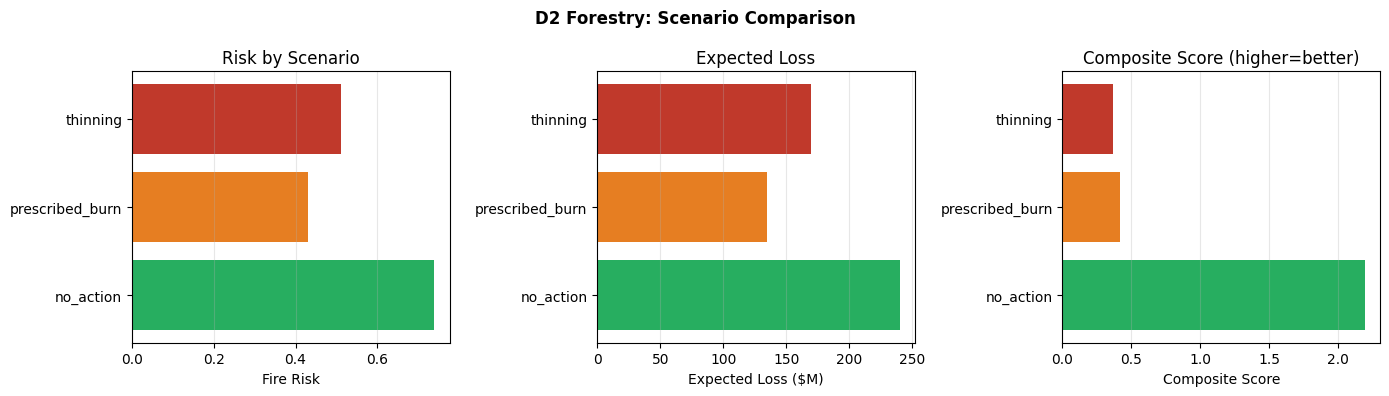

Wrote d2-gp-complex.json


In [4]:
scenarios = {

    "no_action":       {"risk": 0.74, "cost_musd": 0.0,  "expected_loss_musd": 240.0},

    "thinning":        {"risk": 0.51, "cost_musd": 65.0, "expected_loss_musd": 170.0},

    "prescribed_burn": {"risk": 0.43, "cost_musd": 92.0, "expected_loss_musd": 135.0},

}

report = build_scenario_report(scenarios["no_action"], scenarios["prescribed_burn"], higher_is_better=[])

report_path = export_scenario_report(report, OUTPUT_DIR / "d2-gp-scenario-report.json")

print("Scenario report:", report_path)



scenario_records = []

for name, vals in scenarios.items():

    score = round((1 - vals["risk"]) * 0.5 + (1.0 / max(vals["cost_musd"] + 1, 1)) * 10 * 0.2

                  + (1.0 / vals["expected_loss_musd"]) * 50 * 0.3, 4)

    scenario_records.append({"scenario": name, **vals, "score": score})

scenario_records.sort(key=lambda r: -float(r["score"]))



fig, axes = plt.subplots(1, 3, figsize=(14, 4))

names = [r["scenario"] for r in scenario_records]

colors = ["#27ae60", "#e67e22", "#c0392b"]

axes[0].barh(names, [r["risk"] for r in scenario_records], color=colors)

axes[0].set_xlabel("Fire Risk"); axes[0].set_title("Risk by Scenario"); axes[0].grid(True, axis="x", alpha=0.3)

axes[1].barh(names, [r["expected_loss_musd"] for r in scenario_records], color=colors)

axes[1].set_xlabel("Expected Loss ($M)"); axes[1].set_title("Expected Loss"); axes[1].grid(True, axis="x", alpha=0.3)

axes[2].barh(names, [r["score"] for r in scenario_records], color=colors)

axes[2].set_xlabel("Composite Score"); axes[2].set_title("Composite Score (higher=better)"); axes[2].grid(True, axis="x", alpha=0.3)

plt.suptitle("D2 Forestry: Scenario Comparison", fontweight="bold")

plt.tight_layout(); plt.show()



(OUTPUT_DIR / "d2-gp-complex.json").write_text(

    json.dumps({"scenario_ranking": scenario_records}, indent=2, default=str), encoding="utf-8"

)

print("Wrote d2-gp-complex.json")
